# Is OECD adult obesity still rising, plateauing, or reversing?

A widely shared chart suggested that adult obesity might be levelling off — or even
*reversing* — across OECD countries. This notebook tests that claim properly.

The headline difficulty is **measurement and composition**, not the trend itself:

- OECD obesity data is **survey-wave based**: the latest year differs by country, and
  the set of reporting countries changes from year to year. A naive cross-country
  average each year therefore mixes a *real* trend with a *composition* artifact.
- **Self-reported** BMI systematically understates obesity relative to **measured** BMI,
  and the two methodologies have different country coverage.

So we avoid the trap of reading a single line chart. Instead we:

1. rebuild the data from source with caching and provenance;
2. audit coverage and quantify the **measured vs self-reported** gap;
3. estimate **within-country** trends with uncertainty (each country compared to itself,
   which is immune to composition);
4. pool those trends with **fixed-effects** and **mixed** models;
5. formally test for a **post-2013 slowdown**;
6. show why the **population-weighted** series looks like it crashes (and fix it);
7. visualise everything interactively.

### Key findings (spoilers)

- **Within countries, obesity is still rising**: about **+0.34 percentage points per year
  (≈3.4 pp/decade)**, 95% CI [2.5, 4.2], p ≈ 3×10⁻¹⁵.
- There is **no statistically significant slowdown after 2013** (slope change ≈ −0.04
  pp/yr, p ≈ 0.5).
- The apparent "reversal" in the latest years is a **composition artifact**: in 2024 only
  five small countries report and the United States drops out, so the weighted average
  falls even though no country's obesity fell.
- **Self-reported rates understate measured obesity by ≈3.8 pp on average** — the gap that
  makes cross-source comparisons misleading.

> **Verdict:** the data does **not** support a broad reversal. Adult obesity continued to
> rise across OECD countries over the last two decades, with a handful of countries
> plausibly plateauing.

## 1. Setup

`pandas`/`numpy` for data, `matplotlib`/`seaborn` for static plots, `plotly` for
interactive maps and charts, `statsmodels` for the trend inference, and `requests` for
the OECD and World Bank APIs. Everything is cached locally on first run with a provenance
record, so reruns are offline-reproducible.

In [1]:
from __future__ import annotations

import hashlib
import json
import warnings
from dataclasses import dataclass
from datetime import datetime, timezone
from io import StringIO
from pathlib import Path
from typing import Final, Sequence

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import statsmodels.formula.api as smf

pio.renderers.default = "notebook_connected"
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE: Final[int] = 42

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
PROJECT_DIR: Final[Path] = Path.cwd()
DATA_DIR: Final[Path] = PROJECT_DIR / "data"
RAW_DIR: Final[Path] = DATA_DIR / "raw"
PROCESSED_DIR: Final[Path] = DATA_DIR / "processed"
OUTPUT_DIR: Final[Path] = PROJECT_DIR / "outputs"
FIGURE_DIR: Final[Path] = OUTPUT_DIR / "figures"
INTERACTIVE_DIR: Final[Path] = OUTPUT_DIR / "interactive"
PROVENANCE_PATH: Final[Path] = RAW_DIR / "provenance.json"

for directory in (RAW_DIR, PROCESSED_DIR, FIGURE_DIR, INTERACTIVE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# OECD member ISO-3 codes and canonical display names (defined here so the notebook
# never depends on the OECD label column, which can arrive mis-encoded).
OECD_MEMBERS: Final[dict[str, str]] = {
    "AUS": "Australia", "AUT": "Austria", "BEL": "Belgium", "CAN": "Canada",
    "CHL": "Chile", "COL": "Colombia", "CRI": "Costa Rica", "CZE": "Czechia",
    "DNK": "Denmark", "EST": "Estonia", "FIN": "Finland", "FRA": "France",
    "DEU": "Germany", "GRC": "Greece", "HUN": "Hungary", "ISL": "Iceland",
    "IRL": "Ireland", "ISR": "Israel", "ITA": "Italy", "JPN": "Japan",
    "KOR": "Korea", "LVA": "Latvia", "LTU": "Lithuania", "LUX": "Luxembourg",
    "MEX": "Mexico", "NLD": "Netherlands", "NZL": "New Zealand", "NOR": "Norway",
    "POL": "Poland", "PRT": "Portugal", "SVK": "Slovak Republic", "SVN": "Slovenia",
    "ESP": "Spain", "SWE": "Sweden", "CHE": "Switzerland", "TUR": "Türkiye",
    "GBR": "United Kingdom", "USA": "United States",
}

BENCHMARK_YEAR: Final[int] = 2010   # centring year for trend models
BREAKPOINT_YEAR: Final[int] = 2013  # tested for a recent slowdown

In [3]:
def record_provenance(source: str, url: str, local_path: Path, n_records: int) -> None:
    """Append a provenance record (URL, fetch time, SHA-256, row count) to disk."""
    digest = (
        hashlib.sha256(local_path.read_bytes()).hexdigest()
        if local_path.exists() else None
    )
    record = {
        "source": source, "url": url, "local_path": str(local_path),
        "fetched_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "sha256": digest, "n_records": int(n_records),
    }
    existing = json.loads(PROVENANCE_PATH.read_text()) if PROVENANCE_PATH.exists() else []
    existing = [r for r in existing if r.get("source") != source]
    existing.append(record)
    PROVENANCE_PATH.write_text(json.dumps(existing, indent=2))

## 2. Acquire the data

Two official sources, both cached after first download:

- **OECD Body weight** (SDMX API) — self-reported and measured obesity shares.
- **World Bank total population** — used later to weight countries by people, not votes.

In [4]:
OECD_BODY_WEIGHT_API_URL: Final[str] = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.ELS.HD,DSD_HEALTH_LVNG@DF_HEALTH_LVNG_BW/"
    ".A..._T..MSRD+SR"
    "?startPeriod=2000&dimensionAtObservation=AllDimensions&format=csvfilewithlabels"
)
RAW_OECD_CSV_PATH: Final[Path] = RAW_DIR / "oecd_body_weight_raw.csv"


def download_oecd_csv(url: str = OECD_BODY_WEIGHT_API_URL,
                      cache_path: Path = RAW_OECD_CSV_PATH,
                      *, force: bool = False, timeout: int = 90) -> pd.DataFrame:
    """Download the OECD body-weight CSV, validating the payload and caching it."""
    if cache_path.exists() and not force:
        print(f"Loading cached OECD data: {cache_path}")
        frame = pd.read_csv(cache_path, low_memory=False)
    else:
        print(f"Downloading OECD data from {url[:70]}...")
        resp = requests.get(url, timeout=timeout,
                            headers={"User-Agent": "oecd-obesity-analysis/3.0"})
        if resp.status_code != 200:
            raise RuntimeError(f"OECD download failed ({resp.status_code}): {resp.text[:300]}")
        text = resp.text.strip()
        if not text or text.lower().startswith(("<!doctype html", "<html")):
            raise RuntimeError("OECD API returned HTML/empty (rate limit or endpoint change).")
        frame = pd.read_csv(StringIO(text), low_memory=False)
        if frame.empty:
            raise RuntimeError("OECD API returned an empty table.")
        cache_path.write_text(text)
        print(f"Saved raw OECD data to {cache_path}")
    record_provenance("oecd_body_weight", url, cache_path, len(frame))
    return frame


raw_df = download_oecd_csv()
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df[["REF_AREA", "MEASURE", "METHODOLOGY", "SEX", "AGE", "TIME_PERIOD", "OBS_VALUE"]].head()

Loading cached OECD data: C:\Users\diogo\work_code\ds-projects-portfolio\projects\oecd_obesity_analysis_notebook\data\raw\oecd_body_weight_raw.csv
Raw shape: 1,744 rows x 28 columns


,REF_AREA,MEASURE,METHODOLOGY,SEX,AGE,TIME_PERIOD,OBS_VALUE
0,AUS,SP_OBS,SR,_T,_T,2017,19.5
1,AUS,SP_OBS,SR,_T,_T,2022,25.4
2,AUT,SP_OBS,SR,_T,_T,2006,12.4
3,AUT,SP_OBS,SR,_T,_T,2014,14.3
4,AUT,SP_OBS,SR,_T,_T,2017,15.0


In [5]:
WORLD_BANK_INDICATOR: Final[str] = "SP.POP.TOTL"
RAW_POPULATION_PATH: Final[Path] = RAW_DIR / "world_bank_population_oecd.csv"


def download_world_bank_population(country_codes: Sequence[str],
                                   cache_path: Path = RAW_POPULATION_PATH,
                                   *, force: bool = False, timeout: int = 90) -> pd.DataFrame:
    """Download annual total population from the World Bank API, cached locally."""
    keep = ["country_code", "year", "population"]
    if cache_path.exists() and not force:
        print(f"Loading cached population data: {cache_path}")
        pop = pd.read_csv(cache_path)[keep]   # normalise: ignore any extra cached columns
        record_provenance("world_bank_population", "cache", cache_path, len(pop))
        return pop

    codes = ";".join(sorted({str(c) for c in country_codes}))
    url = f"https://api.worldbank.org/v2/country/{codes}/indicator/{WORLD_BANK_INDICATOR}"
    resp = requests.get(url, params={"format": "json", "per_page": 20000},
                        timeout=timeout, headers={"User-Agent": "oecd-obesity-analysis/3.0"})
    if resp.status_code != 200:
        raise RuntimeError(f"World Bank request failed ({resp.status_code}).")
    payload = resp.json()
    if not isinstance(payload, list) or len(payload) < 2 or payload[1] is None:
        raise RuntimeError(f"Unexpected World Bank payload: {str(payload)[:200]}")
    rows = [
        {"country_code": r.get("countryiso3code"), "year": int(r["date"]),
         "population": float(r["value"])}
        for r in payload[1] if r.get("value") is not None
    ]
    pop = pd.DataFrame(rows).dropna().sort_values(["country_code", "year"]).reset_index(drop=True)
    if pop.empty:
        raise RuntimeError("World Bank returned no usable population records.")
    pop.to_csv(cache_path, index=False)
    record_provenance("world_bank_population", url, cache_path, len(pop))
    print(f"Saved population data to {cache_path}")
    return pop


population = download_world_bank_population(list(OECD_MEMBERS))
population.head()

Loading cached population data: C:\Users\diogo\work_code\ds-projects-portfolio\projects\oecd_obesity_analysis_notebook\data\raw\world_bank_population_oecd.csv


,country_code,year,population
0,AUS,1960,10276477.0
1,AUS,1961,10483000.0
2,AUS,1962,10742000.0
3,AUS,1963,10950000.0
4,AUS,1964,11167000.0


## 3. Clean the OECD data (code-based, not text-based)

The raw file ships clean **code** columns, so we filter on those directly instead of
fuzzy text matching:

- `MEASURE == "SP_OBS"` — share of population who are obese (not overweight, not the
  combined "overweight or obese" measure);
- `METHODOLOGY in {"SR", "MSRD"}` — self-reported vs measured;
- `SEX == "_T"` and `AGE == "_T"` — totals (adults 15+).

We key country identity on the ISO-3 `REF_AREA` code and attach our own canonical names,
so a mis-encoded label column can never corrupt the analysis.

In [6]:
METHODOLOGY_LABELS: Final[dict[str, str]] = {"SR": "Self-reported", "MSRD": "Measured"}


def clean_oecd_body_weight(df: pd.DataFrame) -> pd.DataFrame:
    """Filter to adult total obesity rates for OECD members and tidy the columns."""
    required = {"REF_AREA", "MEASURE", "METHODOLOGY", "SEX", "AGE", "TIME_PERIOD", "OBS_VALUE"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Raw data is missing expected columns: {sorted(missing)}")

    mask = (
        (df["MEASURE"] == "SP_OBS")
        & (df["METHODOLOGY"].isin(METHODOLOGY_LABELS))
        & (df["SEX"] == "_T")
        & (df["AGE"] == "_T")
        & (df["REF_AREA"].isin(OECD_MEMBERS))
    )
    work = df.loc[mask].copy()

    work["country_code"] = work["REF_AREA"].astype(str)
    work["country"] = work["country_code"].map(OECD_MEMBERS)
    work["methodology"] = work["METHODOLOGY"].map(METHODOLOGY_LABELS)
    work["year"] = pd.to_numeric(work["TIME_PERIOD"], errors="coerce").astype("Int64")
    work["obesity_rate"] = pd.to_numeric(work["OBS_VALUE"], errors="coerce")

    tidy = (
        work[["country_code", "country", "year", "methodology", "obesity_rate"]]
        .dropna()
        .groupby(["country_code", "country", "year", "methodology"], as_index=False)
        .agg(obesity_rate=("obesity_rate", "mean"))
        .sort_values(["methodology", "country", "year"])
        .reset_index(drop=True)
    )
    return tidy


obesity_all = clean_oecd_body_weight(raw_df)
self_reported = obesity_all[obesity_all["methodology"] == "Self-reported"].copy()
measured = obesity_all[obesity_all["methodology"] == "Measured"].copy()

for name, frame in [("oecd_obesity_clean_all_methodologies", obesity_all),
                    ("oecd_obesity_self_reported", self_reported),
                    ("oecd_obesity_measured", measured)]:
    frame.to_csv(PROCESSED_DIR / f"{name}.csv", index=False)

print(f"All: {obesity_all.shape}  |  Self-reported: {self_reported.shape}  |  Measured: {measured.shape}")
obesity_all.head()

All: (474, 5)  |  Self-reported: (322, 5)  |  Measured: (152, 5)


,country_code,country,year,methodology,obesity_rate
0,AUS,Australia,2007,Measured,24.6
1,AUS,Australia,2011,Measured,28.3
2,AUS,Australia,2014,Measured,27.9
3,AUS,Australia,2017,Measured,30.4
4,AUS,Australia,2022,Measured,30.7


### Validate before trusting

A few assertions guard against the failure modes that silently corrupt this kind of
panel: implausible rates, malformed codes, duplicate country-year-method rows, or an
empty table after filtering.

In [7]:
def validate_panel(df: pd.DataFrame) -> None:
    """Assert structural and value invariants on the tidy obesity panel."""
    assert not df.empty, "Cleaned panel is empty - check the OECD schema/filters."
    assert df["obesity_rate"].between(0, 80).all(), "Obesity rate outside 0-80%."
    assert df["country_code"].str.len().eq(3).all(), "Country codes must be ISO-3."
    assert df["methodology"].isin(["Self-reported", "Measured"]).all(), "Bad methodology label."
    assert not df.duplicated(["country_code", "year", "methodology"]).any(), "Duplicate rows."
    assert df["country_code"].isin(OECD_MEMBERS).all(), "Non-OECD code present."
    print(f"Validation passed: {len(df):,} rows, "
          f"{df['country'].nunique()} countries, "
          f"{df['year'].min()}-{df['year'].max()}.")


validate_panel(obesity_all)

Validation passed: 474 rows, 38 countries, 2000-2024.


## 4. Coverage audit: why a single line chart is dangerous

The panel is **unbalanced**. Different countries report in different years, and the
*number* of reporting countries swings wildly from year to year. The heatmap below shows
exactly which country-years exist for self-reported data — the gaps are the reason a
cross-country yearly average is not directly comparable over time.

Self-reported countries reporting per year (last 10):
year
2015    11
2016    10
2017    22
2018     9
2019    22
2020    10
2021    10
2022    18
2023     9
2024     5


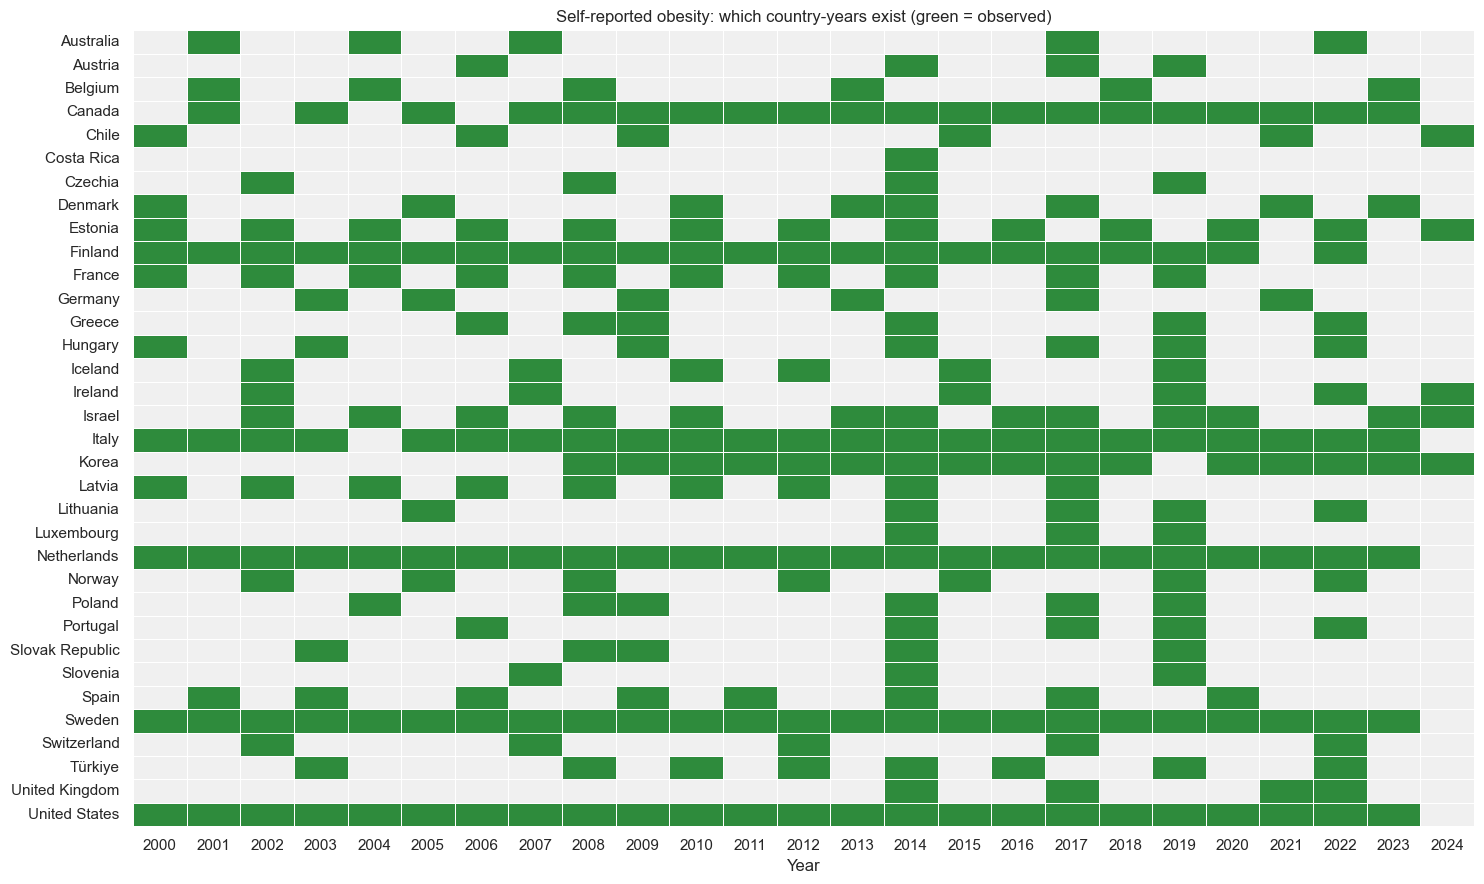

In [8]:
coverage_by_year = (
    self_reported.groupby("year", as_index=False)
    .agg(n_countries=("country", "nunique"),
         mean_rate=("obesity_rate", "mean"),
         median_rate=("obesity_rate", "median"))
)
print("Self-reported countries reporting per year (last 10):")
print(coverage_by_year.set_index("year")["n_countries"].tail(10).to_string())

grid = (self_reported.assign(present=1)
        .pivot_table(index="country", columns="year", values="present", aggfunc="max"))
fig, ax = plt.subplots(figsize=(15, 9))
sns.heatmap(grid.notna(), cmap=["#f0f0f0", "#2E8B3C"], cbar=False, linewidths=0.4,
            linecolor="white", ax=ax)
ax.set(title="Self-reported obesity: which country-years exist (green = observed)",
       xlabel="Year", ylabel="")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "coverage_heatmap_self_reported.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. The measurement gap: self-reported vs measured BMI

People under-report their weight, so **self-reported** obesity is biased **down** relative
to **measured** BMI. The two also have different country coverage. Before comparing
sources or pooling, we quantify this gap on the countries that have **both** (latest
available year each), and fit a simple correction model.

In [9]:
def latest_by_country(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    """Latest available observation per country."""
    idx = df.groupby("country_code")["year"].idxmax()
    return (df.loc[idx, ["country_code", "country", "year", "obesity_rate"]]
            .rename(columns={"year": f"{value_name}_year", "obesity_rate": value_name})
            .reset_index(drop=True))


gap = (latest_by_country(self_reported, "self_reported")
       .merge(latest_by_country(measured, "measured"), on=["country_code", "country"], how="inner"))
gap["gap_measured_minus_self"] = gap["measured"] - gap["self_reported"]
gap.to_csv(PROCESSED_DIR / "measured_vs_self_reported_latest.csv", index=False)

bias_model = smf.ols("measured ~ self_reported", gap).fit()
mean_gap = gap["gap_measured_minus_self"].mean()
print(f"Countries with both methodologies: {len(gap)}")
print(f"Mean (measured - self-reported) gap: {mean_gap:+.2f} pp")
print(f"Bias model:  measured = {bias_model.params['Intercept']:.2f} "
      f"+ {bias_model.params['self_reported']:.3f} * self_reported   "
      f"(R^2 = {bias_model.rsquared:.2f})")

Countries with both methodologies: 20
Mean (measured - self-reported) gap: +3.79 pp
Bias model:  measured = 3.11 + 1.032 * self_reported   (R^2 = 0.71)


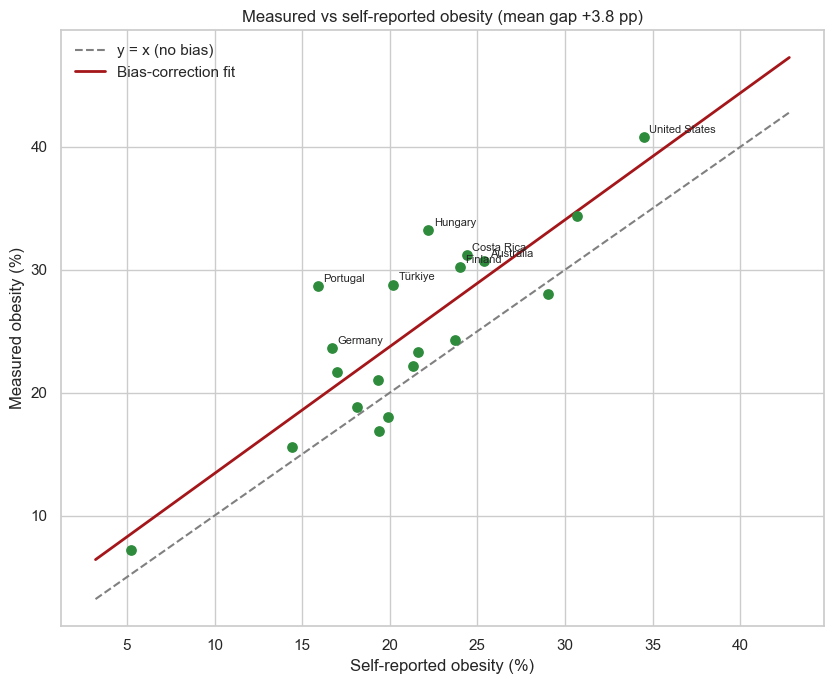

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(gap["self_reported"], gap["measured"], s=45, color="#2E8B3C", zorder=3)
lo = float(min(gap["self_reported"].min(), gap["measured"].min())) - 2
hi = float(max(gap["self_reported"].max(), gap["measured"].max())) + 2
ax.plot([lo, hi], [lo, hi], "--", color="0.5", label="y = x (no bias)")
xs = np.linspace(lo, hi, 50)
ax.plot(xs, bias_model.params["Intercept"] + bias_model.params["self_reported"] * xs,
        color="#A4161A", lw=2, label="Bias-correction fit")
for _, r in gap.iterrows():
    if abs(r["gap_measured_minus_self"]) >= gap["gap_measured_minus_self"].abs().quantile(0.6):
        ax.annotate(r["country"], (r["self_reported"], r["measured"]),
                    xytext=(4, 3), textcoords="offset points", fontsize=8)
ax.set(title=f"Measured vs self-reported obesity (mean gap {mean_gap:+.1f} pp)",
       xlabel="Self-reported obesity (%)", ylabel="Measured obesity (%)")
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "measured_vs_self_reported.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Within-country trends (the composition-immune answer)

A country compared **to itself** over time cannot be fooled by which *other* countries
report in a given year. For each country with at least 5 observations we fit

```text
obesity_rate = intercept + slope * (year - 2010)
```

with ordinary least squares and report the slope, its 95% confidence interval, and
significance. The slope is in percentage points per year.

In [11]:
MIN_OBS_FOR_TREND: Final[int] = 5


def country_trend(group: pd.DataFrame) -> pd.Series:
    """OLS slope (pp/yr) with 95% CI and p-value for one country."""
    g = group.dropna(subset=["year", "obesity_rate"]).sort_values("year")
    out = {"n_obs": g["year"].nunique(), "first_year": g["year"].min(),
           "latest_year": g["year"].max(), "latest_rate": g["obesity_rate"].iloc[-1],
           "slope_per_year": np.nan, "ci_low": np.nan, "ci_high": np.nan,
           "p_value": np.nan, "r_squared": np.nan}
    if g["year"].nunique() >= MIN_OBS_FOR_TREND:
        d = g.assign(year_c=g["year"].astype(float) - BENCHMARK_YEAR)
        m = smf.ols("obesity_rate ~ year_c", d).fit()
        ci = m.conf_int().loc["year_c"]
        out.update(slope_per_year=m.params["year_c"], ci_low=ci[0], ci_high=ci[1],
                   p_value=m.pvalues["year_c"], r_squared=m.rsquared)
    return pd.Series(out)


country_trends = (self_reported.groupby(["country_code", "country"])
                  .apply(country_trend, include_groups=False).reset_index())
country_trends["slope_per_decade"] = 10 * country_trends["slope_per_year"]
country_trends["significant"] = country_trends["p_value"] < 0.05
country_trends = country_trends.sort_values("slope_per_decade", ascending=False)
country_trends.to_csv(PROCESSED_DIR / "country_trend_slopes_self_reported.csv", index=False)

n_sig_pos = int(((country_trends["slope_per_year"] > 0) & country_trends["significant"]).sum())
n_sig_neg = int(((country_trends["slope_per_year"] < 0) & country_trends["significant"]).sum())
n_modelled = int(country_trends["slope_per_year"].notna().sum())
print(f"Countries modelled: {n_modelled}")
print(f"Significantly increasing: {n_sig_pos}   |   significantly decreasing: {n_sig_neg}")
country_trends[["country", "n_obs", "slope_per_decade", "ci_low", "ci_high",
                "p_value", "significant"]].head(10)

Countries modelled: 28
Significantly increasing: 22   |   significantly decreasing: 0


,country,n_obs,slope_per_decade,ci_low,ci_high,p_value,significant
5,Chile,6.0,11.532622,0.562574,1.743951,5.614249e-03,True
12,Finland,22.0,5.265277,0.466880,0.586176,5.200571e-14,True
33,United States,24.0,5.212174,0.494384,0.548051,4.150943e-22,True
32,Türkiye,8.0,4.702290,0.296475,0.643983,5.713578e-04,True
24,Latvia,9.0,4.657007,0.263362,0.668039,9.637743e-04,True
9,Denmark,8.0,4.182678,0.375534,0.461002,3.480530e-07,True
18,Iceland,6.0,4.026095,-0.223283,1.028502,1.486472e-01,False
17,Ireland,6.0,3.958205,-0.010674,0.802315,5.389634e-02,False
3,Canada,20.0,3.820225,0.344617,0.419428,2.852214e-14,True
13,France,10.0,3.795380,0.268012,0.491064,5.013881e-05,True


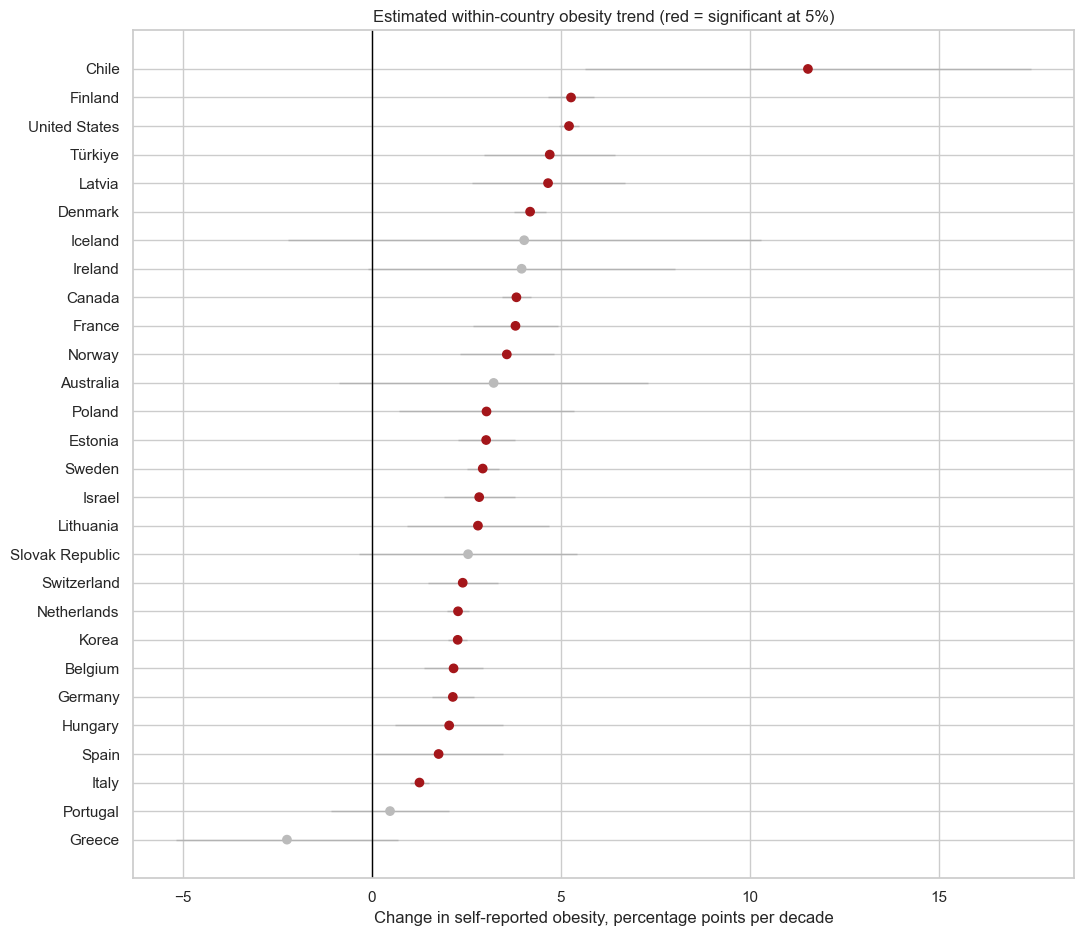

In [12]:
tp = country_trends.dropna(subset=["slope_per_decade"]).sort_values("slope_per_decade")
colors = ["#A4161A" if s else "#bbbbbb" for s in tp["significant"]]
fig, ax = plt.subplots(figsize=(11, max(8, 0.34 * len(tp))))
ax.errorbar(tp["slope_per_decade"], range(len(tp)),
            xerr=[tp["slope_per_decade"] - 10 * tp["ci_low"],
                  10 * tp["ci_high"] - tp["slope_per_decade"]],
            fmt="none", ecolor="0.7", lw=1, zorder=1)
ax.scatter(tp["slope_per_decade"], range(len(tp)), color=colors, zorder=3)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(range(len(tp)))
ax.set_yticklabels(tp["country"])
ax.set(title="Estimated within-country obesity trend (red = significant at 5%)",
       xlabel="Change in self-reported obesity, percentage points per decade")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "country_trend_slopes_self_reported.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Pooling the trend: fixed-effects and mixed models

To get a single OECD-wide trend with honest uncertainty we use two complementary pooled
estimators, both of which isolate the **within-country** change:

- **Country fixed effects** with **cluster-robust** standard errors (clustered by country).
- A **random-intercept mixed model** as an independent cross-check.

A random-*slope* model is tempting but does not converge on this short, unbalanced panel,
so we do not over-fit it; the per-country slopes above already describe slope heterogeneity.

In [13]:
panel = self_reported.assign(year_c=self_reported["year"].astype(float) - BENCHMARK_YEAR)

fe = smf.ols("obesity_rate ~ year_c + C(country_code)", panel).fit(
    cov_type="cluster", cov_kwds={"groups": panel["country_code"]})
fe_ci = fe.conf_int().loc["year_c"]

ri = smf.mixedlm("obesity_rate ~ year_c", panel, groups=panel["country_code"]).fit()
ri_ci = ri.conf_int().loc["year_c"]

pooled = pd.DataFrame({
    "model": ["Country fixed effects (cluster-robust)", "Random-intercept mixed model"],
    "slope_per_year": [fe.params["year_c"], ri.params["year_c"]],
    "ci_low_per_year": [fe_ci[0], ri_ci[0]],
    "ci_high_per_year": [fe_ci[1], ri_ci[1]],
})
pooled["slope_per_decade"] = (10 * pooled["slope_per_year"]).round(2)
pooled["ci_per_decade"] = pooled.apply(
    lambda r: f"[{10*r['ci_low_per_year']:.2f}, {10*r['ci_high_per_year']:.2f}]", axis=1)
pooled.to_csv(PROCESSED_DIR / "pooled_trend_estimates.csv", index=False)
pooled[["model", "slope_per_decade", "ci_per_decade"]]

,model,slope_per_decade,ci_per_decade
0,Country fixed effects (cluster-robust),3.39,"[2.54, 4.23]"
1,Random-intercept mixed model,3.38,"[3.09, 3.68]"


## 8. Is there a recent slowdown? A segmented test

The reversal claim is really a claim about the **recent** slope. We test it directly with
a segmented (piecewise) model that lets the trend change at 2013:

```text
obesity_rate = country_effect + b1 * year_c + b2 * year_c * 1[year >= 2013]
```

`b2` is the **change in slope** after 2013. If the recent slowdown were real, `b2` would
be significantly negative.

In [14]:
panel["post"] = (panel["year"] >= BREAKPOINT_YEAR).astype(int)
seg = smf.ols("obesity_rate ~ year_c + year_c:post + C(country_code)", panel).fit(
    cov_type="cluster", cov_kwds={"groups": panel["country_code"]})

pre_slope = seg.params["year_c"]
slope_change = seg.params["year_c:post"]
print(f"Pre-{BREAKPOINT_YEAR} slope:      {10*pre_slope:+.2f} pp/decade")
print(f"Post-{BREAKPOINT_YEAR} slope change: {10*slope_change:+.2f} pp/decade  "
      f"(p = {seg.pvalues['year_c:post']:.3f})")
print(f"Implied post-{BREAKPOINT_YEAR} slope: {10*(pre_slope+slope_change):+.2f} pp/decade")
verdict = ("NOT statistically significant -> no evidence of a real slowdown"
           if seg.pvalues["year_c:post"] >= 0.05 else
           "statistically significant -> evidence of a slope change")
print(f"\nSlope change is {verdict}.")

Pre-2013 slope:      +3.64 pp/decade
Post-2013 slope change: -0.41 pp/decade  (p = 0.522)
Implied post-2013 slope: +3.23 pp/decade

Slope change is NOT statistically significant -> no evidence of a real slowdown.


## 9. The composition artifact, and how to fix it

A population-weighted yearly average looks authoritative but is **not comparable across
years** when the reporting set changes. In 2024 only five small countries report and the
United States drops out, so the weighted average plunges — even though no country's
obesity actually fell. We show the naive series next to a **balanced-panel** estimate that
holds the country set fixed to those observed across the whole window.

In [15]:
def weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    ok = values.notna() & weights.notna() & weights.gt(0)
    return float(np.average(values[ok], weights=weights[ok])) if ok.any() else np.nan


wp = self_reported.merge(population, on=["country_code", "year"], how="left")

# Naive: every reporting country counted, whatever the set that year.
naive = (wp.groupby("year")
         .apply(lambda g: weighted_mean(g["obesity_rate"], g["population"]), include_groups=False)
         .rename("naive_weighted").reset_index())
naive["n_countries"] = wp.groupby("year")["country"].nunique().values

# Balanced: fixed set of "core" countries observed in most years, forward/back filled,
# so year-to-year changes reflect real movement, not a changing membership.
obs_per_country = self_reported.groupby("country_code")["year"].nunique()
core = obs_per_country[obs_per_country >= 10].index.tolist()
years = range(int(self_reported["year"].min()), int(self_reported["year"].max()) + 1)
full = pd.MultiIndex.from_product([core, years], names=["country_code", "year"]).to_frame(index=False)
bal = full.merge(self_reported[["country_code", "year", "obesity_rate"]],
                 on=["country_code", "year"], how="left")
bal["obesity_rate"] = (bal.sort_values("year").groupby("country_code")["obesity_rate"]
                       .transform(lambda s: s.interpolate().ffill().bfill()))
bal = bal.merge(population, on=["country_code", "year"], how="left")
balanced = (bal.groupby("year")
            .apply(lambda g: weighted_mean(g["obesity_rate"], g["population"]), include_groups=False)
            .rename("balanced_weighted").reset_index())

weighted_series = naive.merge(balanced, on="year")
weighted_series.to_csv(PROCESSED_DIR / "weighted_obesity_series.csv", index=False)
print(f"Balanced panel uses {len(core)} core countries observed in >=10 years.")
weighted_series.tail(8)

Balanced panel uses 10 core countries observed in >=10 years.


,year,naive_weighted,n_countries,balanced_weighted
17,2017,21.041134,22,22.782885
18,2018,24.256120,9,23.227538
19,2019,24.144125,22,23.834058
20,2020,24.891061,10,24.492587
21,2021,24.909122,10,24.599220
22,2022,25.161677,18,24.841336
23,2023,26.579846,9,25.422351
24,2024,13.581268,5,25.486429


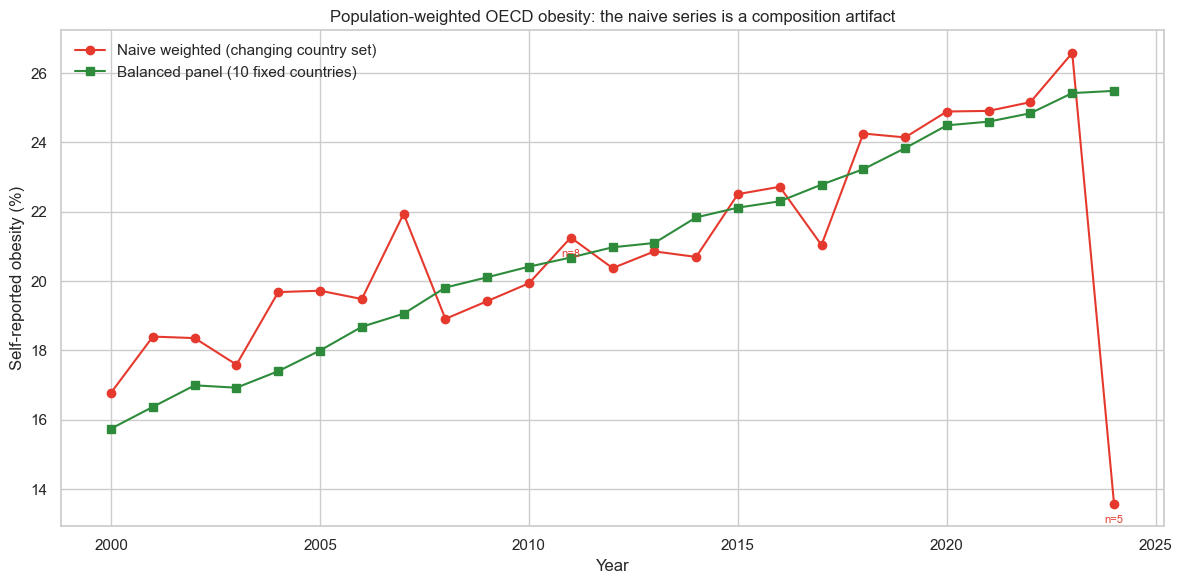

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(naive["year"], naive["naive_weighted"], marker="o", color="#E6392E",
        label="Naive weighted (changing country set)")
ax.plot(balanced["year"], balanced["balanced_weighted"], marker="s", color="#2E8B3C",
        label=f"Balanced panel ({len(core)} fixed countries)")
# Flag the artifact years where few countries report.
for _, r in naive.iterrows():
    if r["n_countries"] <= 8:
        ax.annotate(f"n={int(r['n_countries'])}", (r["year"], r["naive_weighted"]),
                    xytext=(0, -14), textcoords="offset points", ha="center",
                    fontsize=8, color="#E6392E")
ax.set(title="Population-weighted OECD obesity: the naive series is a composition artifact",
       xlabel="Year", ylabel="Self-reported obesity (%)")
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "weighted_artifact_vs_balanced.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Interactive views

Static charts compress a lot. These Plotly figures are interactive in the notebook
(hover for values) and are also saved as standalone HTML in `outputs/interactive/`.

In [17]:
latest_sr = latest_by_country(self_reported, "obesity_rate")
choro = px.choropleth(
    latest_sr, locations="country_code", locationmode="ISO-3", color="obesity_rate",
    hover_name="country", color_continuous_scale="YlOrRd", range_color=(8, 36),
    title="Latest self-reported adult obesity rate by OECD country (%)")
choro.update_geos(showcoastlines=True, projection_type="natural earth")
choro.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0})
choro.write_html(INTERACTIVE_DIR / "choropleth_latest_obesity.html", include_plotlyjs="cdn")
choro.show()

In [18]:
trend_map = country_trends.dropna(subset=["slope_per_decade"]).copy()
choro2 = px.choropleth(
    trend_map, locations="country_code", locationmode="ISO-3", color="slope_per_decade",
    hover_name="country", color_continuous_scale="RdBu_r", color_continuous_midpoint=0,
    hover_data={"slope_per_decade": ":.2f", "p_value": ":.3f"},
    title="Estimated obesity trend by OECD country (pp per decade)")
choro2.update_geos(showcoastlines=True, projection_type="natural earth")
choro2.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0})
choro2.write_html(INTERACTIVE_DIR / "choropleth_trend.html", include_plotlyjs="cdn")
choro2.show()

In [19]:
lines = px.line(
    self_reported.sort_values("year"), x="year", y="obesity_rate", color="country",
    markers=True, title="Self-reported adult obesity over time, by country (hover to isolate)",
    labels={"obesity_rate": "Obesity rate (%)", "year": "Year"})
lines.update_traces(opacity=0.75)
lines.update_layout(legend={"font": {"size": 9}}, margin={"t": 50})
lines.write_html(INTERACTIVE_DIR / "country_lines.html", include_plotlyjs="cdn")
lines.show()

## 11. Synthesis: can we say obesity has reversed?

We combine every strand of evidence into one table, then let a small rule turn it into a
verdict. The point is that the answer rests on *consistent* signals — within-country
trend, its significance, the segmented test, and the count of countries actually
declining — not on a single chart.

In [20]:
n_decline_sig = int(((country_trends["slope_per_year"] < 0) & country_trends["significant"]).sum())
n_rise_sig = int(((country_trends["slope_per_year"] > 0) & country_trends["significant"]).sum())

evidence = pd.DataFrame({
    "signal": [
        "Pooled within-country trend (FE)",
        "Trend 95% CI excludes zero",
        "Post-2013 slope change significant",
        "Countries significantly rising",
        "Countries significantly declining",
        "Mean measured-minus-self-reported gap",
    ],
    "value": [
        f"{10*fe.params['year_c']:+.2f} pp/decade",
        "yes" if (fe_ci[0] > 0 or fe_ci[1] < 0) else "no",
        "yes" if seg.pvalues["year_c:post"] < 0.05 else "no",
        f"{n_rise_sig} of {n_modelled}",
        f"{n_decline_sig} of {n_modelled}",
        f"{mean_gap:+.1f} pp",
    ],
})
evidence.to_csv(OUTPUT_DIR / "evidence_summary.csv", index=False)
evidence

,signal,value
0,Pooled within-country trend (FE),+3.39 pp/decade
1,Trend 95% CI excludes zero,yes
2,Post-2013 slope change significant,no
3,Countries significantly rising,22 of 28
4,Countries significantly declining,0 of 28
5,Mean measured-minus-self-reported gap,+3.8 pp


In [21]:
rising = fe_ci[0] > 0 and fe.params["year_c"] > 0
slowdown = seg.pvalues["year_c:post"] < 0.05 and (fe.params["year_c"] + slope_change) < fe.params["year_c"]

if rising and not slowdown:
    verdict = (
        "The OECD data does NOT support a broad reversal. Within countries, adult obesity "
        f"rose by about {10*fe.params['year_c']:.1f} pp/decade (95% CI "
        f"[{10*fe_ci[0]:.1f}, {10*fe_ci[1]:.1f}]), and there is no statistically "
        "significant slowdown after 2013. The apparent recent dip in cross-country "
        "averages is a composition artifact of which countries report each year, "
        f"and self-reported rates understate measured obesity by ~{mean_gap:.1f} pp. "
        f"Only {n_decline_sig} of {n_modelled} countries show a significant decline."
    )
elif rising and slowdown:
    verdict = ("Obesity is still rising overall, but there is statistically significant "
               "evidence of a recent slowdown that merits country-by-country follow-up.")
else:
    verdict = ("The pooled trend is not clearly positive; the evidence is mixed and "
               "sensitive to coverage and methodology choices.")

print(verdict)

The OECD data does NOT support a broad reversal. Within countries, adult obesity rose by about 3.4 pp/decade (95% CI [2.5, 4.2]), and there is no statistically significant slowdown after 2013. The apparent recent dip in cross-country averages is a composition artifact of which countries report each year, and self-reported rates understate measured obesity by ~3.8 pp. Only 0 of 28 countries show a significant decline.


## 12. Conclusions, limitations, and outputs

**What we did.** Rebuilt the OECD obesity data from source with provenance, audited its
unbalanced coverage, quantified the self-reported-vs-measured gap, estimated
within-country trends with uncertainty, pooled them with fixed-effects and mixed models,
formally tested for a post-2013 slowdown, exposed and fixed the population-weighting
composition artifact, and visualised it all interactively.

**What we found.** Adult obesity continued to rise across OECD countries
(≈3–4 pp/decade within countries), with **no significant recent slowdown**. The
"reversal" impression comes from changing country coverage and from mixing self-reported
and measured data — not from any real downturn.

**Limitations.**

- OECD data is **survey-wave based and unbalanced**; the latest year differs by country.
- **Self-reported** dominates the panel and **understates** obesity; **measured** coverage
  is too sparse for measured-only trends in most countries.
- All estimates are **descriptive**, not causal, and a linear-in-time trend is a
  simplification of what may be a slightly concave curve.
- The balanced-panel weighting trades coverage for comparability and interpolates gaps.

**Reproducibility.** Every remote source is cached under `data/raw/` with a provenance
record (URL, fetch time, SHA-256, row count); dependencies are pinned in
`requirements.txt`; randomness is seeded.

**Main outputs**

- `data/processed/*.csv` — cleaned panel, coverage, bias, per-country and pooled trends, weighted series
- `outputs/evidence_summary.csv` — the synthesis table
- `outputs/figures/*.png` — static figures
- `outputs/interactive/*.html` — interactive choropleths and line chart